In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Core datasets
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")
scheme = pd.read_csv("../data/processed/scheme_performance_clean.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

# Additional datasets
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")
benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")
monthly_sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")
category_inflows = pd.read_csv("../data/processed/category_inflows_clean.csv")
aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")
industry_folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

In [4]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [5]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [6]:
print(scheme.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [7]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [8]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
var_df = nav.groupby('amfi_code')['daily_return'].apply(
    lambda x: np.percentile(x.dropna(),5)
).reset_index()

var_df.columns=['amfi_code','VaR_95']

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [10]:
cvar_list=[]

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code']==fund]

    var = np.percentile(
        temp['daily_return'].dropna(),
        5
    )

    cvar = temp[
        temp['daily_return'] <= var
    ]['daily_return'].mean()

    cvar_list.append([fund,cvar])

cvar_df = pd.DataFrame(
    cvar_list,
    columns=['amfi_code','CVaR']
)

cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [11]:
risk_report = var_df.merge(
    cvar_df,
    on='amfi_code'
)

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
risk_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("CSV file saved successfully!")

CSV file saved successfully!


In [13]:
print(risk_report.shape)

(40, 3)


In [14]:
risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:
risk_report.shape


(40, 3)

In [16]:
top5 = nav['amfi_code'].unique()[:5]

print(top5)

[100016 100025 100033 101206 101207]


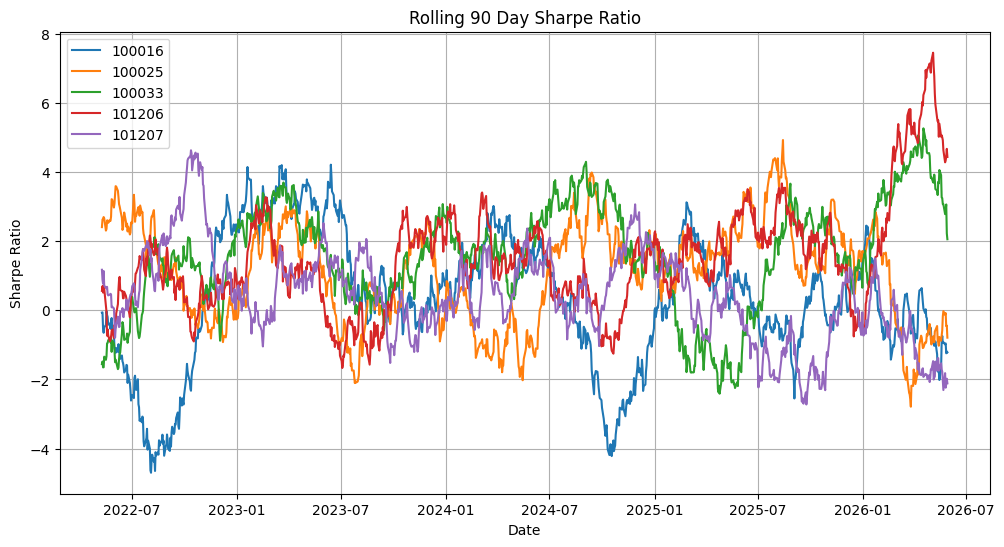

In [17]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp['sharpe'] = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        temp['sharpe'],
        label=str(fund)
    )

plt.legend()

plt.title("Rolling 90 Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.grid(True)

plt.savefig(
    "rolling_sharpe_chart.png"
)

plt.show()

In [18]:
investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

cohort = investor.groupby(
    'investor_id'
)['transaction_date'].min().dt.year

cohort = cohort.reset_index()

cohort.columns = [
    'investor_id',
    'cohort_year'
]

cohort.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [19]:
investor = investor.merge(
    cohort,
    on='investor_id'
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [20]:
avg_sip = investor.groupby(
    'cohort_year'
)['amount_inr'].mean()

avg_sip

cohort_year
2024    107422.541832
2025    109158.577061
Name: amount_inr, dtype: float64

In [21]:
total_invested = investor.groupby(
    'cohort_year'
)['amount_inr'].sum()

total_invested

cohort_year
2024    3491125187
2025      30455243
Name: amount_inr, dtype: int64

In [22]:
top_fund = investor.groupby(
    ['cohort_year', 'amfi_code']
).size()

top_fund = top_fund.reset_index(
    name='count'
)

top_fund.head()

,cohort_year,amfi_code,count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844


In [23]:
top_fund = top_fund.loc[
    top_fund.groupby(
        'cohort_year'
    )['count'].idxmax()
]

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [24]:
cohort_report = pd.DataFrame({
    'avg_sip': avg_sip,
    'total_invested': total_invested
}).reset_index()

cohort_report = cohort_report.merge(
    top_fund[['cohort_year', 'amfi_code']],
    on='cohort_year'
)

cohort_report

,cohort_year,avg_sip,total_invested,amfi_code
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [25]:
cohort_report.to_csv(
    "cohort_analysis_report.csv",
    index=False
)

print("Cohort report saved successfully!")

Cohort report saved successfully!


In [26]:
sip = investor[
    investor['transaction_type'] == "SIP"
]

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [27]:
counts = sip.groupby(
    'investor_id'
).size()

counts.head()

investor_id
INV000001    2
INV000002    3
INV000003    2
INV000004    6
INV000005    3
dtype: int64

In [28]:
valid_ids = counts[
    counts >= 6
].index

len(valid_ids)

1362

In [29]:
sip = sip[
    sip['investor_id'].isin(valid_ids)
]

sip.shape

(9679, 14)

In [30]:
sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024


In [31]:
sip['gap_days'] = sip.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

sip[['investor_id',
     'transaction_date',
     'gap_days']].head(15)

,investor_id,transaction_date,gap_days
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0
12003,INV000004,2024-07-07,59.0
28749,INV000004,2025-03-29,265.0
31897,INV000004,2025-05-17,49.0
9329,INV000008,2024-05-27,NaN
11113,INV000008,2024-06-23,27.0
21549,INV000008,2024-12-05,165.0
24389,INV000008,2025-01-18,44.0


In [32]:
gap = sip.groupby(
    'investor_id'
)['gap_days'].mean()

gap.head()

investor_id
INV000004    85.400000
INV000008    70.400000
INV000010    64.800000
INV000011    40.166667
INV000012    57.000000
Name: gap_days, dtype: float64

In [33]:
at_risk = gap[
    gap > 35
]

at_risk.head()

investor_id
INV000004    85.400000
INV000008    70.400000
INV000010    64.800000
INV000011    40.166667
INV000012    57.000000
Name: gap_days, dtype: float64

In [34]:
print("Number of At-Risk Investors:")
print(len(at_risk))

Number of At-Risk Investors:
1332


In [35]:
at_risk.reset_index().to_csv(
    "at_risk_investors.csv",
    index=False
)

print("At-risk investor report saved!")

At-risk investor report saved!


In [36]:
scheme['risk_grade'].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [37]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [38]:
portfolio['market_value_cr'] = pd.to_numeric(
    portfolio['market_value_cr']
)

portfolio['weight'] = (
    portfolio['market_value_cr']
    /
    portfolio.groupby(
        'amfi_code'
    )['market_value_cr']
    .transform('sum')
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.128913
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.015560
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.036457
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.028214
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.126956


In [39]:
portfolio[
    ['amfi_code',
     'stock_name',
     'weight']
].head()

,amfi_code,stock_name,weight
0,119551,Power Grid Corporation,0.128913
1,119551,HDFC Bank Ltd,0.015560
2,119551,Grasim Industries Ltd,0.036457
3,119551,Dr. Reddy's Laboratories,0.028214
4,119551,Asian Paints Ltd,0.126956


In [40]:
hhi = portfolio.groupby(
    'amfi_code'
)['weight'].apply(
    lambda x: (x**2).sum()
)

hhi = hhi.reset_index(
    name='HHI'
)

hhi.head()

,amfi_code,HHI
0,100016,0.150312
1,100033,0.147021
2,101206,0.137023
3,101207,0.189443
4,102885,0.184522


In [41]:
hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
21,120505,0.193127
15,119551,0.189679
3,101207,0.189443
4,102885,0.184522
26,125497,0.178369
27,125498,0.157455
30,148569,0.155744
31,149322,0.152411
29,148568,0.152001
32,149323,0.150842


In [42]:
hhi.sort_values(
    'HHI'
).head(10)

,amfi_code,HHI
33,149324,0.091904
17,119598,0.103956
20,120504,0.105892
23,120841,0.110090
16,119552,0.110519
24,120842,0.112290
8,118633,0.113399
25,120843,0.114830
11,119092,0.118612
6,102887,0.118647


In [43]:
hhi.to_csv(
    "hhi_report.csv",
    index=False
)

print("HHI report saved successfully!")

HHI report saved successfully!


In [44]:
hhi.head()

,amfi_code,HHI
21,120505,0.193127
15,119551,0.189679
3,101207,0.189443
4,102885,0.184522
26,125497,0.178369


# Advanced Insights

## Insight 1: Highest Downside Risk
Fund with AMFI Code 119599 recorded the worst VaR (95%) of -2.69% and CVaR of -3.24%, indicating the highest downside risk among all analyzed schemes.

## Insight 2: Best Risk-Adjusted Performance
ICICI Pru Liquid Fund - Regular - Growth achieved the highest Sharpe Ratio of 7.68, making it the best-performing fund on a risk-adjusted basis.

## Insight 3: Strong Investor Participation
The 2024 investor cohort contributed the highest investment volume of ₹349.11 million, highlighting strong participation from recently onboarded investors.

## Insight 4: SIP Continuity Risk
A total of 1,332 investors were identified as "at-risk" because their average SIP transaction gap exceeded 35 days, indicating potential discontinuation risk.

## Insight 5: Portfolio Concentration
Fund with AMFI Code 120505 recorded the highest HHI score of 0.1931, suggesting a relatively concentrated portfolio compared to other schemes in the dataset.

In [45]:
risk_report.sort_values('VaR_95').head(1)

,amfi_code,VaR_95,CVaR
22,119599,-0.026859,-0.032384


In [46]:
risk_report.sort_values('CVaR').head(1)

,amfi_code,VaR_95,CVaR
4,101207,-0.026021,-0.032459


In [47]:
hhi.sort_values('HHI', ascending=False).head(1)

,amfi_code,HHI
21,120505,0.193127


In [48]:
scheme.sort_values(
    'sharpe_ratio',
    ascending=False
)[['scheme_name','sharpe_ratio']].head()

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


In [49]:
total_invested.sort_values(
    ascending=False
).head()

cohort_year
2024    3491125187
2025      30455243
Name: amount_inr, dtype: int64